# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model_ricard as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'L': 4,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_density': 1,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'gamma': 2,                             # gamma parameter of the Boltzmann function (transfer function)
     'tau': 300,                                   # temperature parameter for the softmax 
     'T_crossover_ratio': 0,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     'target_set': [-1.0,1.0,1.0,-1.0],
     'input_set':[[-1,-1],[-1,1],[1,-1],[1,1]],
     'majority_ratio': 0.8,                       # output group: [np.ceil(par['majority_ratio']*par['L']):-1]
     'ff_iter': 4,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     #'state_bound': [-10,+10],                    # boundaries on the possibile values of the state
     'J_mutation_radius': 0.05,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.05,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.05,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.7,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'elitist_ratio':0.2,
     #'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 500,                    # number of iterations of the algorithm
     'N_sol': 200}                       # number of solutions (individuals, networks) considered in the simulation

if par['reproduction_ratio'] + par['elitist_ratio'] > 1:
     print(f'Error: expected sum of reproduction ratio and elitist ratio to be at maximum 1, but instead got {par[
          'reproduction_ratio']} + {par['elitist_ratio']} = {par['reproduction_ratio']+par['elitist_ratio']}')

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean, loss_ev, mean_asp = m.evolution(par,verb=2,gen_verb=False,stat=True)

Iteration #0...
Mean loss: 1.0000383243789455
Best loss: 0.9999993097272621
Cumulative Best loss: 0.9999993097272621
Iteration #10...
Mean loss: 1.0000882805950704
Best loss: 0.9999851471250143
Cumulative Best loss: 0.9999851471250143
Iteration #20...
Mean loss: 1.0000789540786987
Best loss: 0.9997481144400798
Cumulative Best loss: 0.9998552198551524
Iteration #30...
Mean loss: 1.0000119928358284
Best loss: 0.9995032585722905
Cumulative Best loss: 0.9995271384832154
Iteration #40...
Mean loss: 0.9999004372274382
Best loss: 0.9979126151329801
Cumulative Best loss: 0.9987066309406463
Iteration #50...
Mean loss: 0.9967332423762316
Best loss: 0.990919817276634
Cumulative Best loss: 0.990919817276634
Iteration #60...
Mean loss: 0.9867077478868232
Best loss: 0.9748439593855392
Cumulative Best loss: 0.975775705551408
Iteration #70...
Mean loss: 0.9748133521263592
Best loss: 0.9556354536347015
Cumulative Best loss: 0.9567142059312042
Iteration #80...
Mean loss: 0.958159245759667
Best loss: 0.9

In [4]:
sol = solutions[0]
for input in par['input_set'][:1]:
    output,state = m.ff(input,sol,par,verb=1)
    print(f'Input:{input} -> Output:{output}')
    print(f'state:{state}')

Pre-state:[-1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
State #0: [ 0.86148037 -0.16963873  0.07410671  0.14994323 -0.98174583 -0.9944854
 -0.42701146  0.32016768  0.99874588  0.4199583   0.80978348 -0.19673438
  0.27236917  0.2116597  -0.50930095 -0.18600688]
Pre-state:[-1.         -0.16963873  0.07410671  0.14994323 -1.         -0.9944854
 -0.42701146  0.32016768  0.99874588  0.4199583   0.80978348 -0.19673438
  0.27236917  0.2116597  -0.50930095 -0.18600688]
State #1: [ 0.85213312 -0.26604175  0.09405182  0.13769729 -0.97271378 -0.99696764
 -0.81060302  0.53876178  0.9995994   0.3003836   0.14420759  0.21974079
  0.91801876  0.70939908  0.37861295 -0.49939698]
Pre-state:[-1.         -0.26604175  0.09405182  0.13769729 -1.         -0.99696764
 -0.81060302  0.53876178  0.9995994   0.3003836   0.14420759  0.21974079
  0.91801876  0.70939908  0.37861295 -0.49939698]
State #2: [ 0.84656579 -0.26720194  0.0512961   0.12869455 -0.97289831 -0.99955727
 -0.97843724  0.699

In [5]:
s = copy.deepcopy(solutions)
losses = []
for n,sol in enumerate(s[:10]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-1, -1] -> Output: -0.05881774531793214
Target distance:0.8858240365284208
Link cost:0.14169193354604856
Input: [-1, 1] -> Output: 0.8118596785569645
Target distance:0.035396780552688724
Link cost:0.14169193354604856
Input: [1, -1] -> Output: 0.10317822576967495
Target distance:0.8042892947336281
Link cost:0.14169193354604856
Input: [1, 1] -> Output: -0.7184425171785577
Target distance:0.07927461613274679
Link cost:0.14169193354604856
loss:0.4511961819868711
Solution #1
Input: [-1, -1] -> Output: -0.09035767137505828
Target distance:0.8274491660262066
Link cost:0.14147624608470946
Input: [-1, 1] -> Output: 0.8143593982231679
Target distance:0.03446243302806434
Link cost:0.14147624608470946
Input: [1, -1] -> Output: 0.07322508242387676
Target distance:0.8589117478482301
Link cost:0.14147624608470946
Input: [1, 1] -> Output: -0.7163579947946586
Target distance:0.08045278711690694
Link cost:0.14147624608470946
loss:0.45031903350485203
Solution #2
Input: [-1, -1] -> Out

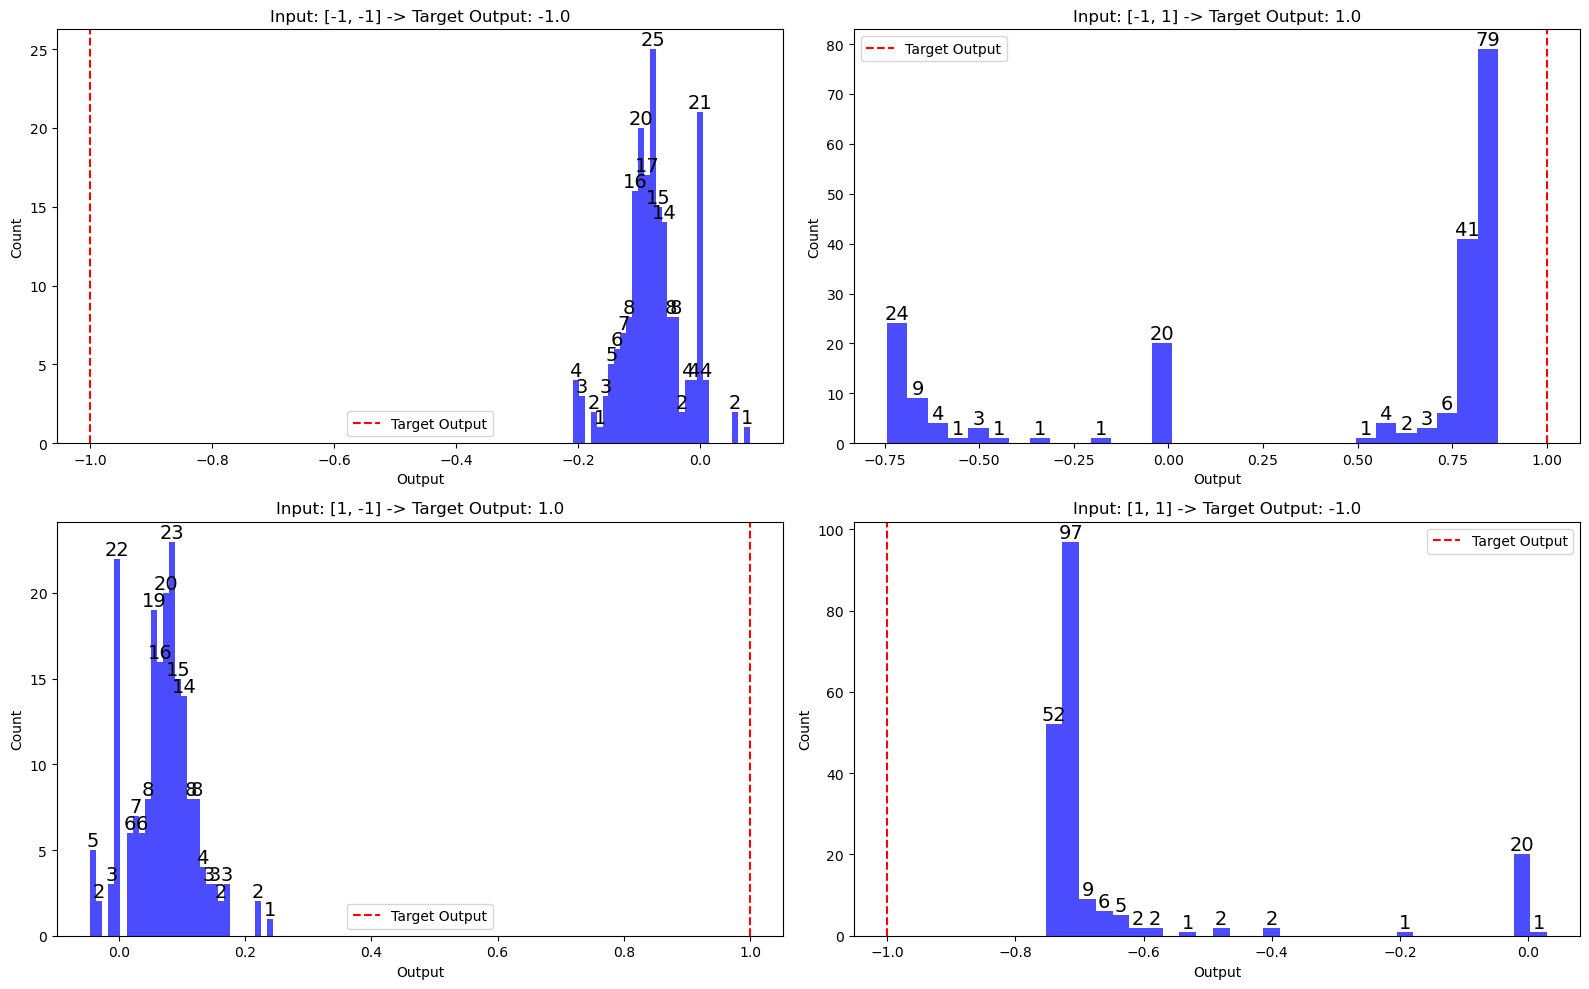

In [6]:
outputs = np.zeros((len(solutions),len(par['input_set'])))
for n,sol in enumerate(solutions):
    for i,input in enumerate(par['input_set']):
        output = m.ff(input,sol,par)
        outputs[n,i] = output

fig, axes = plt.subplots(2, len(par['input_set'])//2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par['target_set'][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r',linestyle='--')
    #ax.set_xticks(list(ax.get_xticks()) + [par['target_set'][i]])
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (patch.get_x() + patch.get_width() / 2, height), 
                        ha='center', va='bottom', fontsize=14)
    ax.legend()
plt.tight_layout()
plt.show()

Links density:0.19140625


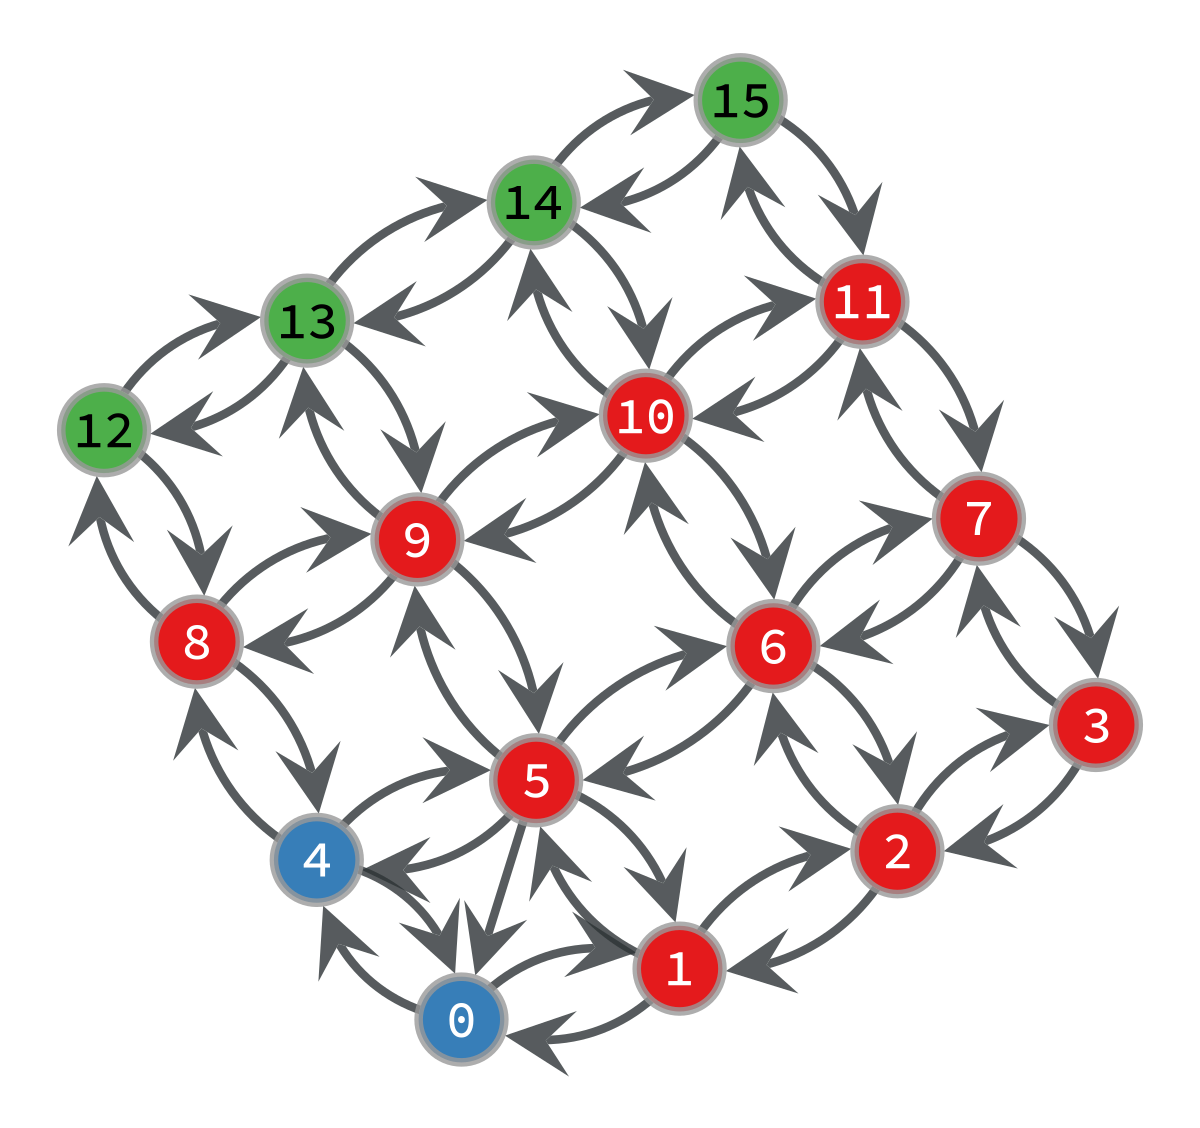

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fdacbe67930, at 0x7fdac3af9860>

In [7]:
print(f'Links density:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

graph = solutions[0].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(0)] = 1
highlight[graph.vertex(par['L'])] = 1
for i in range(int(par['majority_ratio']*(par['L']**2)),graph.num_vertices()):  # outputs
    highlight[graph.vertex(i)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

In [8]:
for input in par['input_set']:
    output,_ = m.ff(input,s[2],par,verb=2)
    print(f'Input:{input} -> Output:{output}')

Pre-state:[-1.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
State #0: [ 0.77500608 -0.09618154  0.09910487  0.53990673 -0.98896707 -0.9999499
 -0.73716102  0.23572061  0.99821257  0.33856772  0.86598127 -0.20767875
 -0.07255999  0.07013131 -0.38242644 -0.4249092 ]
Pre-state:[-1.         -0.09618154  0.09910487  0.53990673 -1.         -0.9999499
 -0.73716102  0.23572061  0.99821257  0.33856772  0.86598127 -0.20767875
 -0.07255999  0.07013131 -0.38242644 -0.4249092 ]
State #1: [ 0.77264746 -0.15992528  0.09592276  0.50820846 -0.9846588  -0.99996822
 -0.90748391  0.54937021  0.99948877  0.5826273   0.1170878   0.18880916
  0.77115289  0.53933281  0.52319223 -0.63593563]
Pre-state:[-1.         -0.15992528  0.09592276  0.50820846 -1.         -0.99996822
 -0.90748391  0.54937021  0.99948877  0.5826273   0.1170878   0.18880916
  0.77115289  0.53933281  0.52319223 -0.63593563]
State #2: [ 0.77107245 -0.15981059  0.02232     0.45895726 -0.98456664 -0.99995113
 -0.9930231   0.577

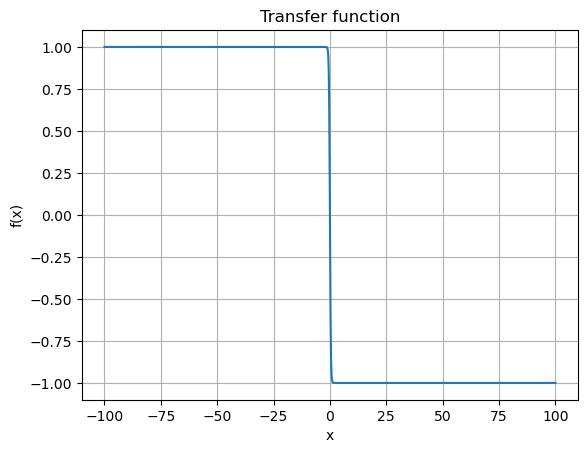

In [9]:
m.plot_T(s[0].T[4],par)

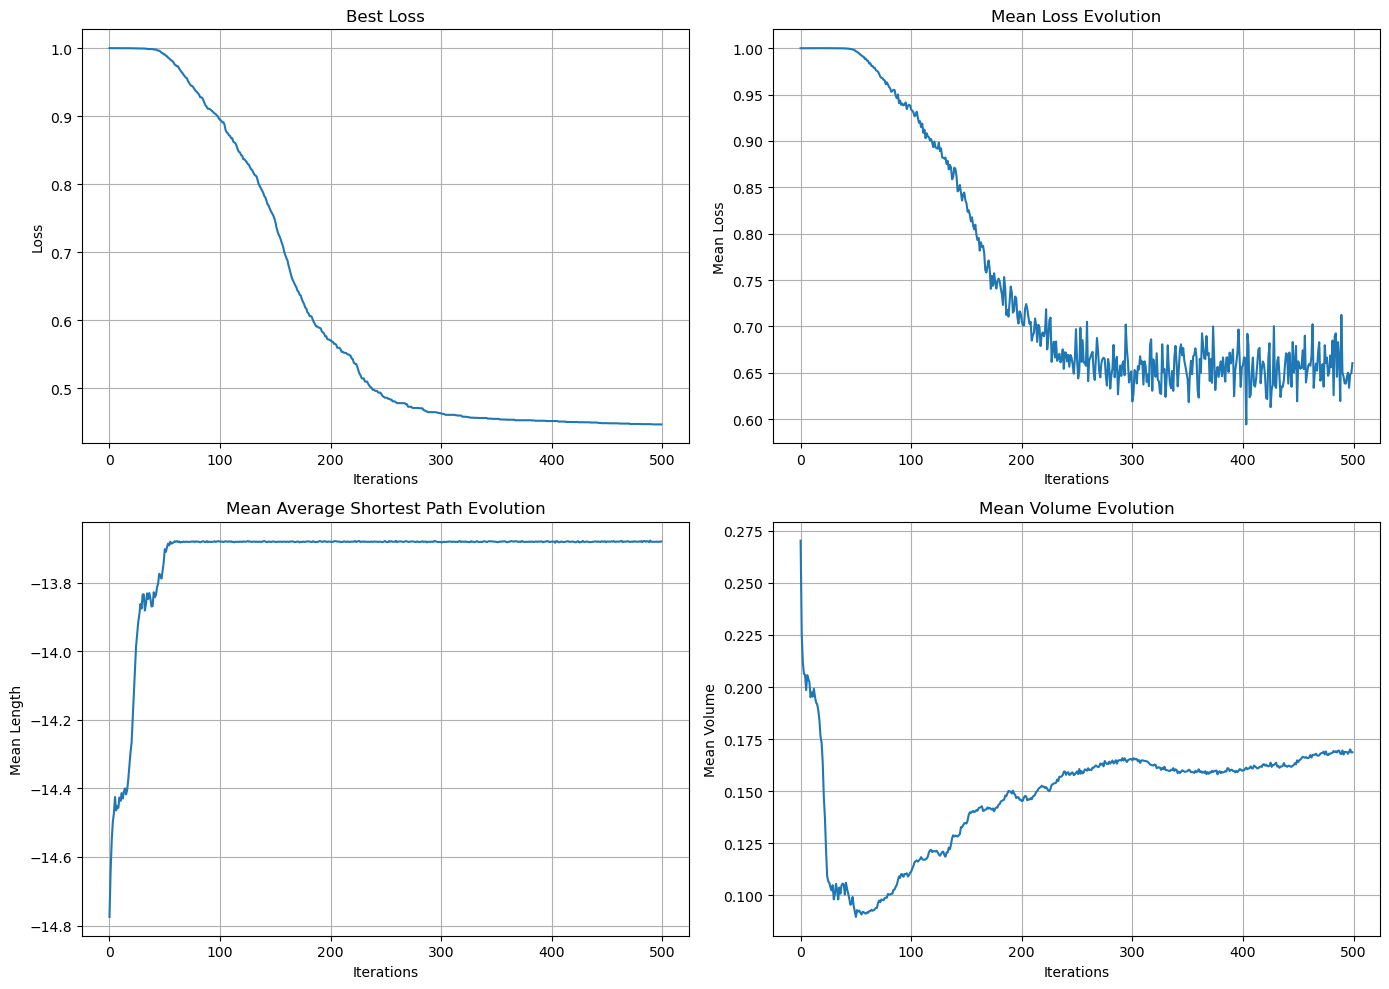

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Best Loss
best_loss = np.min(loss_ev, axis=0)
axs[0, 0].plot(best_loss)
axs[0, 0].set_title('Best Loss')
axs[0, 0].set_xlabel('Iterations')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)

# Mean Loss Evolution
axs[0, 1].plot(np.arange(par['n_iter']), lmean)
axs[0, 1].set_title('Mean Loss Evolution')
axs[0, 1].set_xlabel('Iterations')
axs[0, 1].set_ylabel('Mean Loss')
#axs[0, 1].set_xscale('log')
axs[0, 1].grid(True)

# Mean Average Shortest Path Evolution
axs[1, 0].plot(mean_asp)
axs[1, 0].set_title('Mean Average Shortest Path Evolution')
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('Mean Length')
axs[1, 0].grid(True)

# Mean Volume Evolution
axs[1, 1].plot(volume_mean)
axs[1, 1].set_title('Mean Volume Evolution')
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('Mean Volume')
#axs[1, 1].set_xscale('log')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


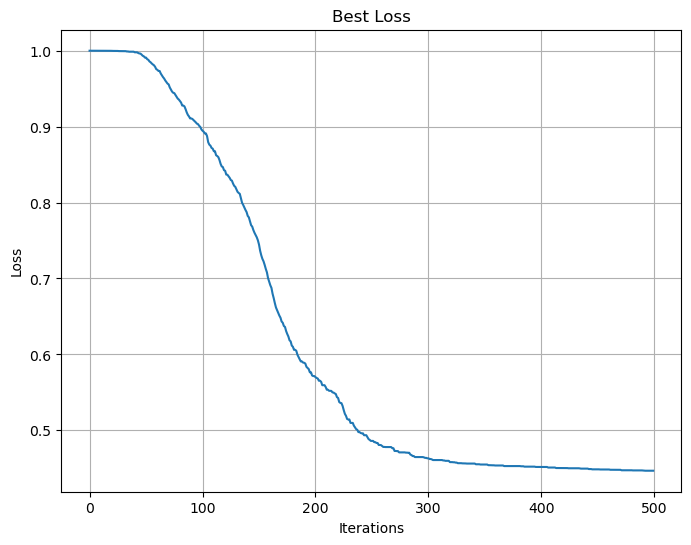

In [11]:
best_loss = np.min(loss_ev, axis=0)
plt.figure(figsize=(8, 6))
plt.plot(best_loss)
plt.title('Best Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()